<a href="https://colab.research.google.com/github/bu11ymaguire/studying/blob/main/ReinforcementLearning/GradientPolicy_baseline_Norm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# 디바이스 설정 (GPU가 사용 가능하면 cuda, 아니면 cpu)
# -----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"학습에 사용되는 디바이스: {device}")

학습에 사용되는 디바이스: cuda


In [3]:
# 1. 정책 및 가치 신경망 (Actor-Critic / Baseline) 정의
class PolicyValueNet(nn.Module):
    def __init__(self, action_size):
        super(PolicyValueNet, self).__init__()
        # 상태 특성을 추출하는 공통 레이어
        self.fc1 = nn.Linear(4, 128)

        # 1) 행동 확률을 출력하는 Policy Head (Actor)
        self.fc_pi = nn.Linear(128, action_size)

        # 2) 상태의 가치(베이스라인)를 예측하는 Value Head (Critic)
        self.fc_v = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))

        # 정책 (행동을 할 확률 분포)
        prob = F.softmax(self.fc_pi(x), dim=1)

        # 상태 가치 평가 (Baseline 값)
        v = self.fc_v(x)

        return prob, v

In [4]:
# 2. 에이전트(Agent) 정의
class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.001  # 정규화와 베이스라인이 추가되었으므로 학습률을 조금 높여도 안정적입니다.
        self.action_size = 2

        self.memory = []
        # 모델을 생성하고 지정된 디바이스(CUDA/CPU)로 이동
        self.net = PolicyValueNet(self.action_size).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=self.lr)

    def get_action(self, state):
        if isinstance(state, tuple):
            state = state[0]

        # 상태를 Float 텐서로 변환 시키고 지정된 디바이스로 전송
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        # 해당 상태의 확률과 평가 가치(v)를 동시에 가져옴
        probs, v = self.net(state)

        m = Categorical(probs)
        action = m.sample()

        return action.item(), probs[0, action.item()], v

    def add(self, reward, prob, v):
        # 이번에는 Baseline 학습을 위해 모델이 예측한 상태 가치(v) 정보도 메모리에 함께 담습니다.
        data = (reward, prob, v)
        self.memory.append(data)

    def update(self):
        self.optimizer.zero_grad()

        # 1. 반환값(G) 계산
        G_list = []
        G = 0
        for reward, _, _ in reversed(self.memory):
            G = reward + self.gamma * G
            G_list.append(G)

        G_list.reverse()
        # 리스트를 텐서로 바꾸고 디바이스 할당
        G_tensor = torch.tensor(G_list, dtype=torch.float32).to(device)

        # 2. 보상 [정규화 (Normalization)]
        if len(G_tensor) > 1:
            G_tensor = (G_tensor - G_tensor.mean()) / (G_tensor.std() + 1e-9)

        # 3. 그래디언트 손실 계산
        policy_loss = 0
        value_loss = 0

        for i, (reward, prob, v) in enumerate(self.memory):
            # [어드밴티지 계산]: 실제 받은 총 보상(G) - 모델이 예상한 가치 베이스라인(v)
            advantage = G_tensor[i] - v.item()

            # Policy Loss (REINFORCE with Baseline)
            policy_loss += -torch.log(prob) * advantage

            # Value Loss (생성해둔 베이스라인 네트워크를 실제 보상에 맞춰 학습되게끔 MSE 오차 계산)
            value_loss += F.mse_loss(v.squeeze(), G_tensor[i])

        # 총 손실 = 정책 네트워크 오차 + 가치 네트워크 오차
        loss = policy_loss + value_loss
        loss.backward()
        self.optimizer.step()

        self.memory = []

In [5]:
# 3. 환경 및 학습 루프
episodes = 800  # 성능이 대폭 향상되어 3000 에피소드까지 진행하지 않아도 됩니다!
env = gym.make('CartPole-v1')
agent = Agent()
reward_history = []

for episode in range(episodes):
    state = env.reset()[0]
    done = False
    total_reward = 0

    while not done:
        # 가치(v)도 함께 반환받음
        action, prob, v = agent.get_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated | truncated

        # 메모리에 가치(v) 추가
        agent.add(reward, prob, v)
        state = next_state
        total_reward += reward

    agent.update()
    reward_history.append(total_reward)

    # 50 단위로 점유율 확인
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode + 1} / {episodes}: Total Reward = {total_reward}")

Episode 50 / 800: Total Reward = 41.0
Episode 100 / 800: Total Reward = 59.0
Episode 150 / 800: Total Reward = 53.0
Episode 200 / 800: Total Reward = 32.0
Episode 250 / 800: Total Reward = 77.0
Episode 300 / 800: Total Reward = 220.0
Episode 350 / 800: Total Reward = 211.0
Episode 400 / 800: Total Reward = 188.0
Episode 450 / 800: Total Reward = 163.0
Episode 500 / 800: Total Reward = 313.0
Episode 550 / 800: Total Reward = 202.0
Episode 600 / 800: Total Reward = 161.0
Episode 650 / 800: Total Reward = 486.0
Episode 700 / 800: Total Reward = 255.0
Episode 750 / 800: Total Reward = 410.0
Episode 800 / 800: Total Reward = 500.0


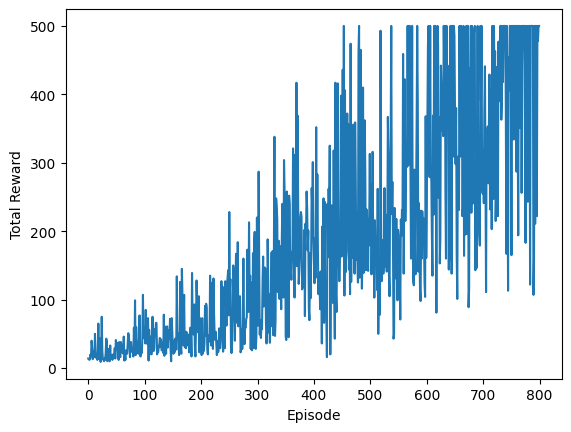

In [6]:
def plot_total_reward(reward_history):
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.plot(range(len(reward_history)), reward_history)
    plt.show()

plot_total_reward(reward_history)